# ZTF AGN Lightcurve Pipeline
Queries the SDSS QSO catalog, cross-matches to ZTF via the IRSA LC-API,
stores g+r lightcurves in HDF5, and provides analysis utilities.

**Cells in order:**
1. Config (TOML string — edit here)
2. Imports & logging
3. Filter profile plot (SDSS / ZTF / LSST)
4. Pipeline: SDSS query → ZTF fetch → HDF5 write
5. Analysis: metadata inspection, epoch filtering, lightcurve plot

In [1]:
import tomllib

TOML_CONFIG = """
[pipeline]
target_n          = 10       # desired number of successfully saved objects
oversample        = 2         # SDSS objects queried = target_n * oversample
search_radius_arcsec = 3.0    # ZTF cone search radius
bad_catflags_mask = 32768     # ZTF bad-epoch bitmask
request_delay_sec = 0.5       # polite pause between IRSA requests
max_retries       = 3         # per-request retry attempts
backoff_base_sec  = 2.0       # exponential backoff base (doubles each retry)
bands             = ["g", "r"]

[storage]
output_hdf5  = "ztf_agn_lc.h5"
hdf5_lc_root = "ztf_agn_lc"        # HDF5 group for lightcurves
hdf5_meta_key = "ztf_agn_metadata"  # HDF5 key for metadata table

[analysis]
# Epoch filters applied when selecting objects for inspection.
# Set to 0 / very large number to disable a bound.
min_g_epochs = 0
max_g_epochs = 99999
min_r_epochs = 0
max_r_epochs = 99999

# Redshift / classification filters (empty string = no filter)
min_redshift  = 0.0
max_redshift  = 99.0
sdss_class    = ""        # e.g. "QSO"
sdss_subclass = ""        # e.g. "Seyfert", "BROADLINE", etc.

[filter_plot]
wl_min_angstrom = 3000
wl_max_angstrom = 11000
"""

cfg = tomllib.loads(TOML_CONFIG)
print("Config loaded.")
print(f"  target_n={cfg['pipeline']['target_n']}, "
      f"bands={cfg['pipeline']['bands']}, "
      f"output={cfg['storage']['output_hdf5']}")


Config loaded.
  target_n=10, bands=['g', 'r'], output=ztf_agn_lc.h5


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import warnings, time, logging
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from astroquery.sdss import SDSS
from astroquery.svo_fps import SvoFps
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.io import ascii as astropy_ascii

try:
    from tables import NaturalNameWarning
    warnings.filterwarnings("ignore", category=NaturalNameWarning)
except ImportError:
    pass

# Root logger — INFO to notebook, suppress noisy sub-loggers
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)
log = logging.getLogger("ztf_pipeline")
logging.getLogger("astropy").setLevel(logging.WARNING)
logging.getLogger("astroquery").setLevel(logging.WARNING)
print("Imports OK.")


Imports OK.


Fetching filter profiles from SVO...


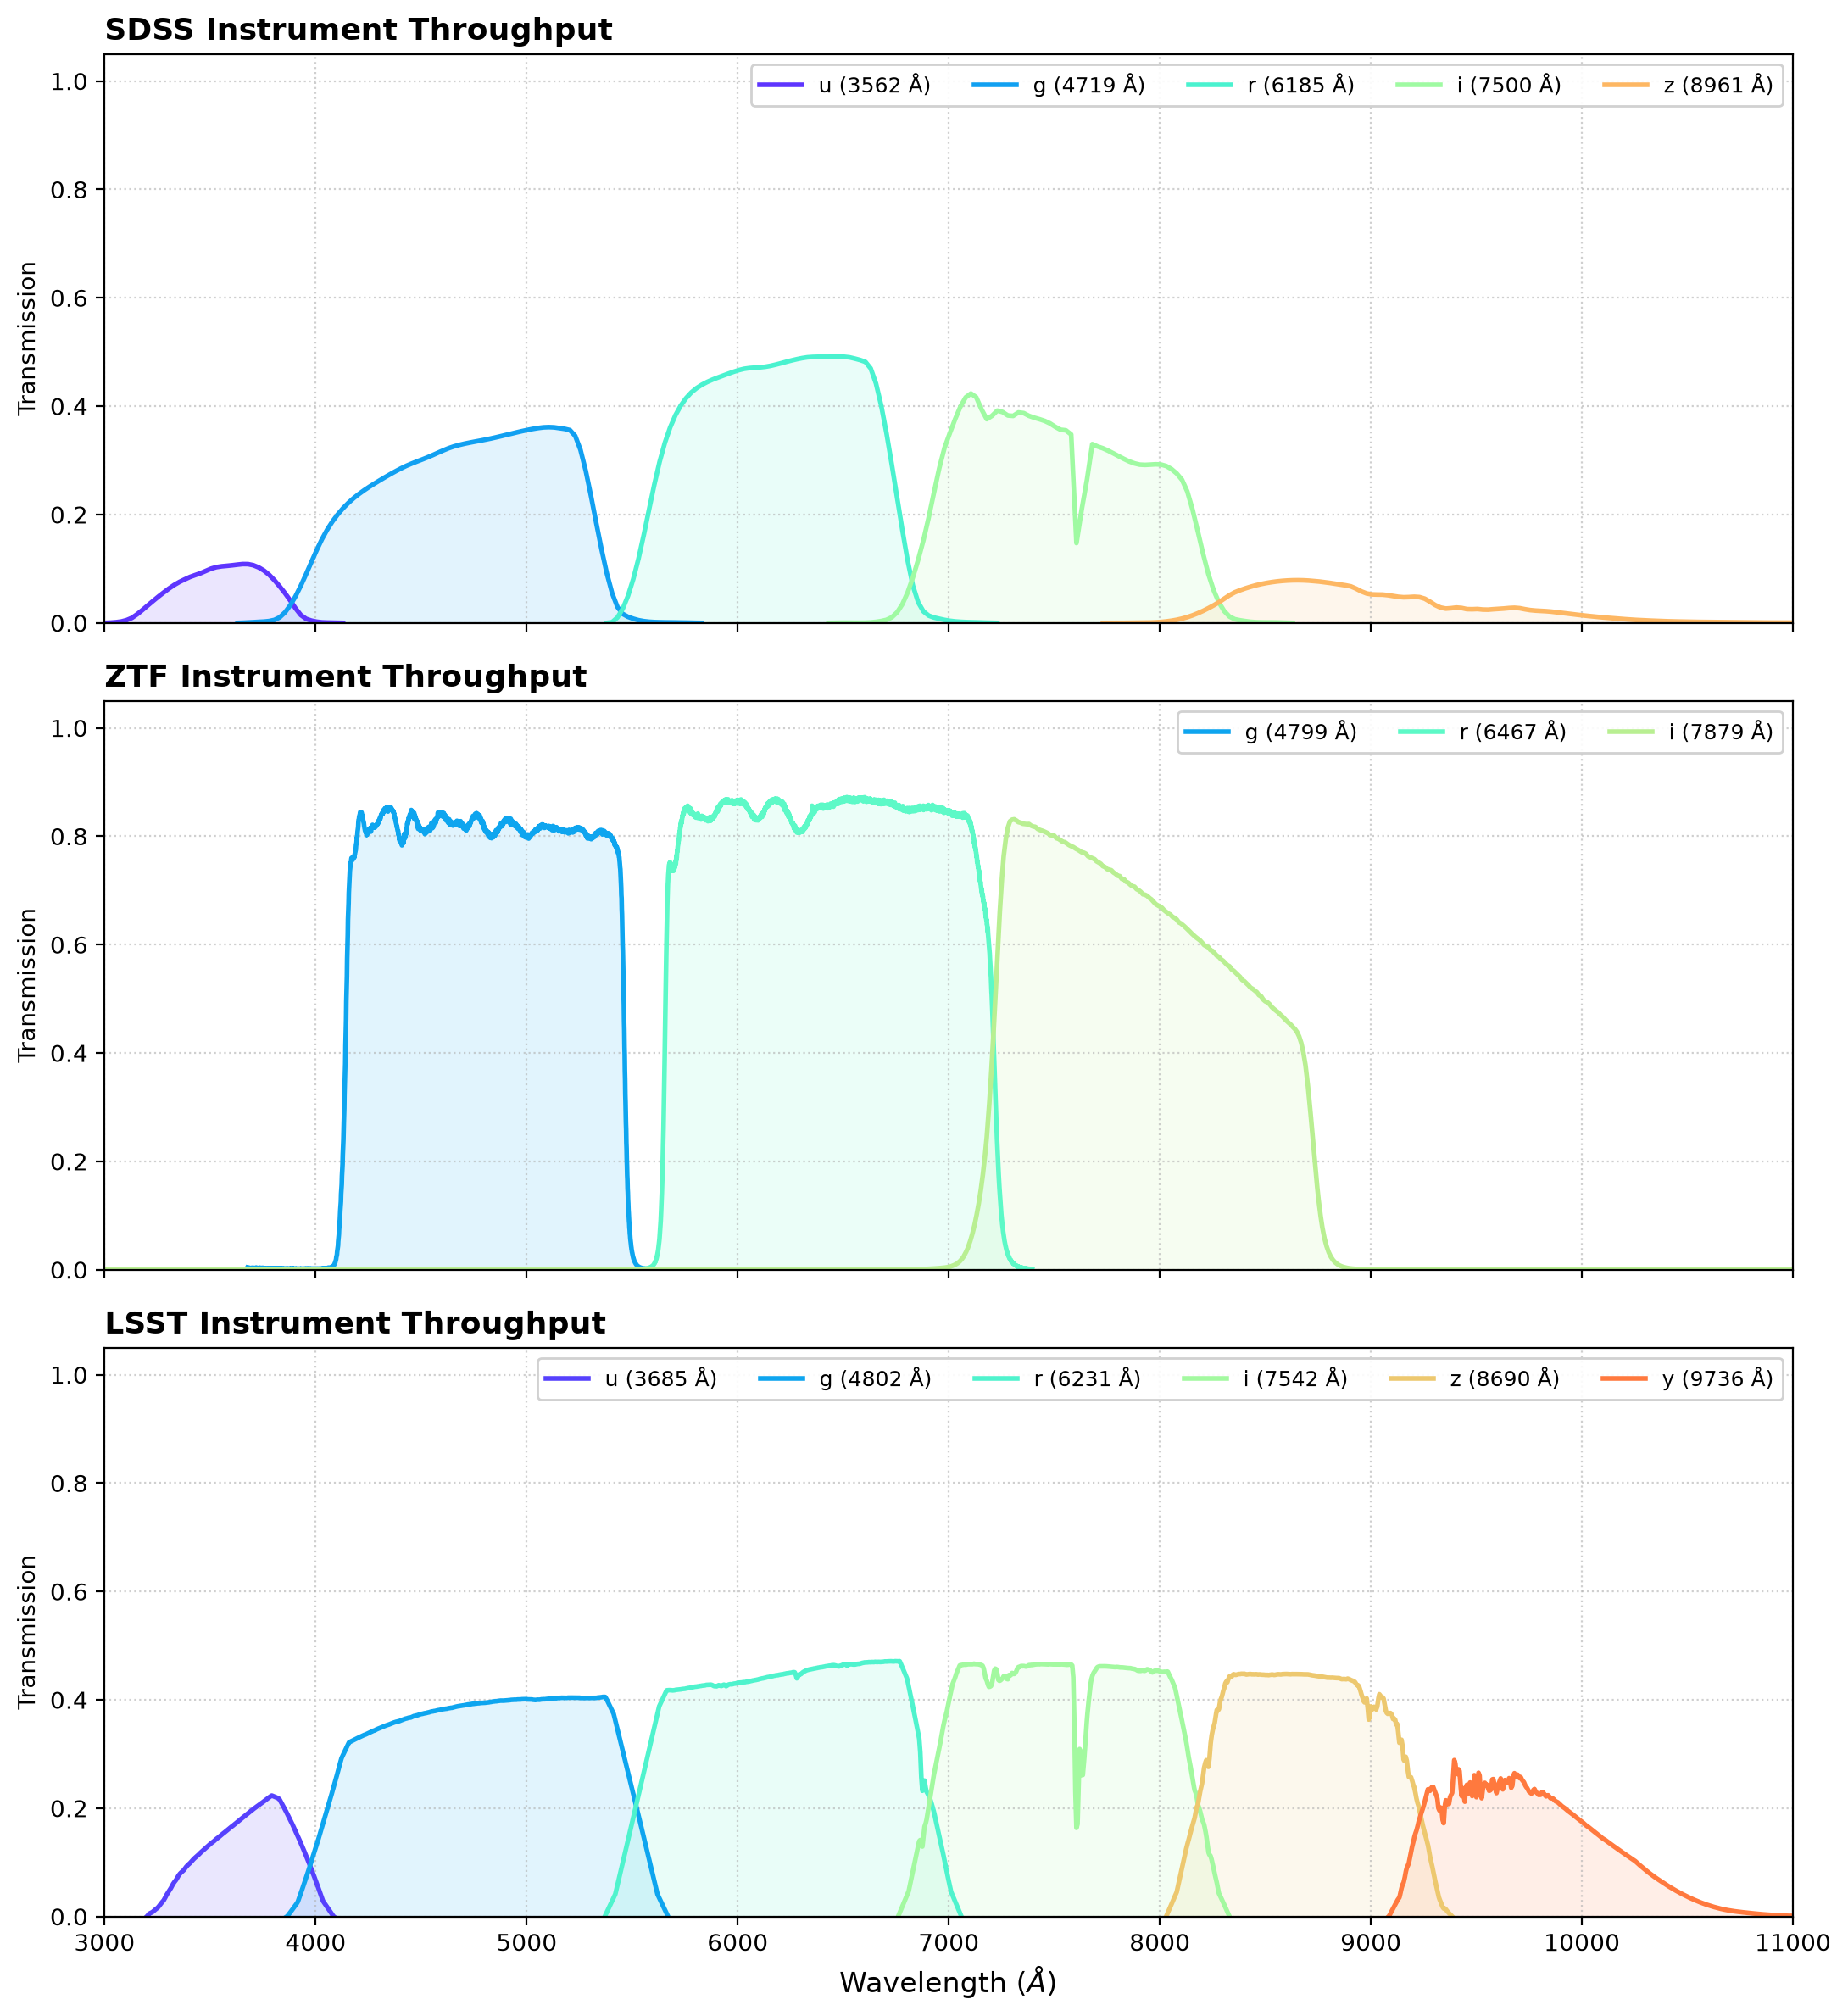

In [3]:
# ── Filter Profile Plot ────────────────────────────────────────────────
# Colours are derived from each filter's SVO transmission-weighted
# central wavelength, mapped onto matplotlib's rainbow colormap.
# No manual colour table needed.

FILTER_SURVEYS = {
    "SDSS": {"prefix": "SLOAN/SDSS.", "bands": ["u","g","r","i","z"]},
    "ZTF":  {"prefix": "Palomar/ZTF.", "bands": ["g","r","i"]},
    "LSST": {"prefix": "LSST/LSST.",  "bands": ["u","g","r","i","z","y"]},
}

WL_MIN = cfg["filter_plot"]["wl_min_angstrom"]
WL_MAX = cfg["filter_plot"]["wl_max_angstrom"]


def wl_to_color(wl: float) -> tuple:
    """Map a wavelength (Angstroms) to a rainbow colormap colour."""
    norm = np.clip((wl - WL_MIN) / (WL_MAX - WL_MIN), 0, 1)
    return plt.cm.rainbow(norm)


def central_wavelength(transmission_table) -> float:
    """Transmission-weighted mean wavelength from an SVO filter table."""
    wl = transmission_table["Wavelength"].astype(float)
    tr = transmission_table["Transmission"].astype(float)
    return float(np.average(wl, weights=np.clip(tr, 0, None)))


def plot_filter_profiles(
    surveys: dict = FILTER_SURVEYS,
    wl_min: float = WL_MIN,
    wl_max: float = WL_MAX,
) -> None:
    """
    Fetch ZTF/SDSS/LSST filter transmission curves from SVO and plot them.
    Each filter is coloured by its transmission-weighted central wavelength.
    """
    fig, axes = plt.subplots(
        nrows=len(surveys), ncols=1,
        figsize=(11, 4 * len(surveys)),
        sharex=True,
    )
    if len(surveys) == 1:
        axes = [axes]

    print("Fetching filter profiles from SVO...")
    for ax, (name, info) in zip(axes, surveys.items()):
        for band in info["bands"]:
            filter_id = f"{info['prefix']}{band}"
            try:
                data = SvoFps.get_transmission_data(filter_id)
                wl   = data["Wavelength"].astype(float)
                tr   = data["Transmission"].astype(float)
                cwl  = central_wavelength(data)
                col  = wl_to_color(cwl)
                ax.plot(wl, tr, label=f"{band} ({cwl:.0f} Å)",
                        color=col, lw=2)
                ax.fill_between(wl, tr, alpha=0.12, color=col)
            except Exception as exc:
                print(f"  Warning: could not fetch {filter_id}: {exc}")

        ax.set_title(f"{name} Instrument Throughput",
                     fontsize=13, fontweight="bold", loc="left")
        ax.set_ylabel("Transmission")
        ax.set_ylim(0, 1.05)
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend(loc="upper right", ncol=len(info["bands"]),
                  framealpha=0.9, fontsize=9)

    axes[-1].set_xlabel(r"Wavelength ($\AA$)", fontsize=12)
    axes[-1].set_xlim(wl_min, wl_max)
    plt.tight_layout()
    plt.show()


plot_filter_profiles()


In [4]:
# ── Pipeline: SDSS → ZTF → HDF5 ───────────────────────────────────────

# Unpack config for convenience
_pc  = cfg["pipeline"]
_sc  = cfg["storage"]

TARGET_N           = _pc["target_n"]
OVERSAMPLE         = _pc["oversample"]
SEARCH_RADIUS_DEG  = _pc["search_radius_arcsec"] / 3600.0
BAD_CATFLAGS_MASK  = _pc["bad_catflags_mask"]
REQUEST_DELAY_SEC  = _pc["request_delay_sec"]
MAX_RETRIES        = _pc["max_retries"]
BACKOFF_BASE       = _pc["backoff_base_sec"]
BANDS              = _pc["bands"]   # ["g", "r"]

OUTPUT_HDF5    = Path(_sc["output_hdf5"])
HDF5_LC_ROOT   = _sc["hdf5_lc_root"]
HDF5_META_KEY  = _sc["hdf5_meta_key"]

ZTF_LC_API     = "https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves"
ZTF_BAND_CODES = {"g": "zg", "r": "zr", "i": "zi"}


# ── 4a. SDSS query ──────────────────────────────────────────────────────

def build_sdss_sql(limit: int, min_bestobjid: int = 0) -> str:
    """
    Build a deterministic SDSS QSO SQL query.
    Uses WHERE bestobjid > min_bestobjid for pagination without OFFSET.
    """
    return f"""
    SELECT TOP {limit}
        s.bestobjid,
        s.ra,
        s.dec,
        s.z        AS redshift,
        s.class,
        s.subclass
    FROM SpecObj AS s
    WHERE
        s.class       = 'QSO'
        AND s.bestobjid IS NOT NULL
        AND s.bestobjid > {min_bestobjid}
    GROUP BY
        s.bestobjid, s.ra, s.dec, s.z, s.class, s.subclass
    ORDER BY
        s.bestobjid
    """


def query_sdss_batch(limit: int, min_bestobjid: int = 0) -> pd.DataFrame:
    """Fetch one batch of SDSS QSOs and return a deduplicated DataFrame."""
    sql = build_sdss_sql(limit, min_bestobjid)
    result = SDSS.query_sql(sql)
    if result is None or len(result) == 0:
        return pd.DataFrame()
    df = result.to_pandas()
    df = df.drop_duplicates(subset="bestobjid").reset_index(drop=True)
    # Ensure correct types
    df["bestobjid"] = df["bestobjid"].astype(np.int64)
    df["redshift"]  = pd.to_numeric(df["redshift"], errors="coerce")
    return df


# ── 4b. ZTF IRSA fetch with retry ───────────────────────────────────────

def fetch_ztf_lc(ra: float, dec: float) -> pd.DataFrame | None:
    """Cone-search IRSA ZTF LC-API; return raw epoch DataFrame or None."""
    band_str = ",".join(BANDS)
    params = {
        "POS":               f"CIRCLE {ra} {dec} {SEARCH_RADIUS_DEG}",
        "BANDNAME":          band_str,
        "BAD_CATFLAGS_MASK": BAD_CATFLAGS_MASK,
        "FORMAT":            "ipac_table",
    }
    try:
        resp = requests.get(ZTF_LC_API, params=params, timeout=30)
        resp.raise_for_status()
    except requests.RequestException as exc:
        raise ConnectionError(str(exc)) from exc

    if not resp.text.strip() or "oid" not in resp.text:
        return None

    table = astropy_ascii.read(resp.text, format="ipac")
    if len(table) == 0:
        return None

    df = table.to_pandas()
    for col in ("ra", "dec", "hjd", "mag", "magerr", "catflags", "oid"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def fetch_ztf_lc_with_retry(ra: float, dec: float) -> pd.DataFrame | None:
    """Wrap fetch_ztf_lc with exponential-backoff retries."""
    for attempt in range(MAX_RETRIES):
        try:
            return fetch_ztf_lc(ra, dec)
        except Exception as exc:
            wait = BACKOFF_BASE ** attempt
            log.warning(
                "  IRSA error (attempt %d/%d): %s — retrying in %.0fs",
                attempt + 1, MAX_RETRIES, exc, wait,
            )
            time.sleep(wait)
    log.error("  All %d retries exhausted for RA=%.5f Dec=%.5f", MAX_RETRIES, ra, dec)
    return None


# ── 4c. Band matching & lightcurve assembly ──────────────────────────────

def select_best_oid_per_band(
    lc_df: pd.DataFrame, ra: float, dec: float
) -> dict[str, int | None]:
    """
    For each requested band, pick the ZTF oid whose median position is
    closest to (ra, dec). Returns {band_code: oid_or_None}.
    """
    source_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
    result = {ZTF_BAND_CODES[b]: None for b in BANDS}

    for band_code in result:
        band_df = lc_df[lc_df["filtercode"] == band_code]
        best_oid, best_sep = None, np.inf
        for oid, grp in band_df.groupby("oid"):
            coord = SkyCoord(
                ra=grp["ra"].median() * u.deg,
                dec=grp["dec"].median() * u.deg,
            )
            sep = source_coord.separation(coord).arcsec
            if sep < best_sep:
                best_sep = sep
                best_oid = oid
        result[band_code] = best_oid

    return result


def build_merged_lightcurve(
    lc_df: pd.DataFrame,
    oids:  dict[str, int | None],
) -> pd.DataFrame | None:
    """
    Build a time-union DataFrame from the best oid for each band.
    Columns: time_g, mag_g, magerr_g, time_r, mag_r, magerr_r
    Each row is one epoch in one band; the other band columns are NaN.
    No scalar metadata (oids, redshift) is stored here.
    """
    frames = []
    band_map = {"zg": ("g", "time_g","mag_g","magerr_g"),
                "zr": ("r", "time_r","mag_r","magerr_r"),
                "zi": ("i", "time_i","mag_i","magerr_i")}

    for band_code, (_, tcol, mcol, ecol) in band_map.items():
        if band_code not in oids or oids[band_code] is None:
            continue
        sub = lc_df[lc_df["oid"] == oids[band_code]][
            ["hjd","mag","magerr"]
        ].copy()
        sub = sub.rename(columns={"hjd": tcol, "mag": mcol, "magerr": ecol})
        frames.append(sub.reset_index(drop=True))

    if not frames:
        return None

    merged = pd.concat(frames, axis=0, ignore_index=True)
    # Sort by whichever time column is non-NaN
    time_cols = [c for c in merged.columns if c.startswith("time_")]
    merged["_t"] = merged[time_cols].bfill(axis=1).iloc[:, 0]
    merged = (
        merged.sort_values("_t")
              .drop(columns="_t")
              .reset_index(drop=True)
    )
    return merged


# ── 4d. HDF5 I/O ────────────────────────────────────────────────────────

def save_lightcurve(bestobjid: int, lc: pd.DataFrame,
                    store: pd.HDFStore) -> None:
    key = f"/{HDF5_LC_ROOT}/{bestobjid}"
    store.put(key, lc, format="fixed")


def save_metadata(meta_rows: list[dict], store: pd.HDFStore) -> None:
    """
    Write (or overwrite) the metadata table into the HDFStore.
    Columns: bestobjid, ra, dec, redshift, class, subclass,
             oid_g, oid_r  (and oid_i if i-band enabled)
    """
    meta_df = pd.DataFrame(meta_rows)
    meta_df["bestobjid"] = meta_df["bestobjid"].astype(np.int64)
    store.put(f"/{HDF5_META_KEY}", meta_df, format="fixed")


# ── 4e. Main pipeline loop ───────────────────────────────────────────────

def run_pipeline() -> pd.DataFrame:
    """
    Run the full acquisition pipeline.
    Returns the metadata DataFrame for immediate inspection.
    Stops and warns if the SDSS queue is exhausted before TARGET_N saves.
    """
    batch_size     = TARGET_N * OVERSAMPLE
    saved          = 0
    n_no_ztf       = 0
    n_retry_fail   = 0
    min_bestobjid  = 0   # pagination cursor
    meta_rows      = []
    seen_bestobjids = set()

    log.info(
        "Starting pipeline: target_n=%d, oversample=%d, batch_size=%d",
        TARGET_N, OVERSAMPLE, batch_size,
    )

    with pd.HDFStore(OUTPUT_HDF5, mode="w", complevel=5,
                     complib="blosc") as store:
        while saved < TARGET_N:
            log.info(
                "Fetching SDSS batch (limit=%d, min_bestobjid=%d) …",
                batch_size, min_bestobjid,
            )
            sdss_df = query_sdss_batch(batch_size, min_bestobjid)

            if sdss_df.empty:
                log.warning(
                    "SDSS queue exhausted after %d saves (target was %d). "
                    "Consider raising oversample or lowering target_n.",
                    saved, TARGET_N,
                )
                break

            # Update pagination cursor to the last bestobjid in this batch
            min_bestobjid = int(sdss_df["bestobjid"].max())

            for _, row in sdss_df.iterrows():
                if saved >= TARGET_N:
                    break

                bestobjid = int(row["bestobjid"])
                if bestobjid in seen_bestobjids:
                    continue
                seen_bestobjids.add(bestobjid)

                ra, dec = float(row["ra"]), float(row["dec"])
                log.info(
                    "[%4d/%d] bestobjid=%d  RA=%.5f  Dec=%.5f",
                    saved + 1, TARGET_N, bestobjid, ra, dec,
                )

                # ZTF fetch with retry
                lc_df = fetch_ztf_lc_with_retry(ra, dec)
                time.sleep(REQUEST_DELAY_SEC)

                if lc_df is None or lc_df.empty:
                    log.debug("  → no ZTF detections")
                    n_no_ztf += 1
                    continue

                # Best oid per band
                oids = select_best_oid_per_band(lc_df, ra, dec)
                if all(v is None for v in oids.values()):
                    n_no_ztf += 1
                    continue

                # Build time-series
                lc = build_merged_lightcurve(lc_df, oids)
                if lc is None or lc.empty:
                    n_retry_fail += 1
                    continue

                # Write lightcurve (pure time-series, no scalars)
                lc_key = f"/{HDF5_LC_ROOT}/{bestobjid}"
                if lc_key in store:
                    log.warning("  → %d already in store, skipping", bestobjid)
                    continue
                save_lightcurve(bestobjid, lc, store)

                # Accumulate metadata (all scalars live here)
                meta_row = {
                    "bestobjid": bestobjid,
                    "ra":        ra,
                    "dec":       dec,
                    "redshift":  float(row["redshift"])
                              if pd.notna(row["redshift"]) else np.nan,
                    "sdss_class":    str(row.get("class", "")),
                    "sdss_subclass": str(row.get("subclass", "")),
                }
                # One oid column per band (None → NaN)
                for band_code, oid_val in oids.items():
                    band_letter = band_code[1]  # "zg" → "g"
                    meta_row[f"oid_{band_letter}"] = (
                        int(oid_val) if oid_val is not None else pd.NA
                    )

                meta_row["g_epochs"] = int(lc["mag_g"].notna().sum()) \
                    if "mag_g" in lc.columns else 0
                meta_row["r_epochs"] = int(lc["mag_r"].notna().sum()) \
                    if "mag_r" in lc.columns else 0

                meta_rows.append(meta_row)
                saved += 1

                log.info(
                    "  → saved (%d/%d)  oid_g=%s  oid_r=%s  "
                    "g=%d epochs  r=%d epochs",
                    saved, TARGET_N,
                    oids.get("zg"), oids.get("zr"),
                    meta_row["g_epochs"], meta_row["r_epochs"],
                )

        # Write metadata table once, after all objects are processed
        if meta_rows:
            save_metadata(meta_rows, store)
            log.info("Metadata table written (%d rows).", len(meta_rows))

    log.info("=" * 60)
    log.info("Pipeline complete.")
    log.info("  Saved      : %d / %d", saved, TARGET_N)
    log.info("  No ZTF match : %d", n_no_ztf)
    log.info("  Other skips  : %d", n_retry_fail)
    log.info("  Output       : %s", OUTPUT_HDF5)
    log.info("=" * 60)

    return pd.DataFrame(meta_rows)


metadata = run_pipeline()


02:26:27  INFO      Starting pipeline: target_n=10, oversample=2, batch_size=20
02:26:27  INFO      Fetching SDSS batch (limit=20, min_bestobjid=0) …
02:26:29  INFO      [   1/10] bestobjid=1197126704423239975  RA=238.23135  Dec=55.93361
02:26:52  INFO        → saved (1/10)  oid_g=794110100014215  oid_r=794210100017828  g=1151 epochs  r=1281 epochs
02:26:52  INFO      [   2/10] bestobjid=1197126704428810393  RA=238.55945  Dec=43.16305
02:27:12  INFO        → saved (2/10)  oid_g=721113300015990  oid_r=721213300002028  g=1010 epochs  r=1129 epochs
02:27:12  INFO      [   3/10] bestobjid=1197126704428875838  RA=238.43512  Dec=43.10423
02:27:38  INFO        → saved (3/10)  oid_g=721113300006600  oid_r=721213300002536  g=1275 epochs  r=1319 epochs
02:27:38  INFO      [   4/10] bestobjid=1197126704428875872  RA=238.49717  Dec=43.15542
02:27:49  INFO        → saved (4/10)  oid_g=721113300001248  oid_r=721213300002106  g=1242 epochs  r=1309 epochs
02:27:49  INFO      [   5/10] bestobjid=119712

Total objects in store: 10
             bestobjid  redshift sdss_subclass  g_epochs  r_epochs
0  1197126704423239975  0.338289     BROADLINE      1151      1281
1  1197126704428810393  1.770023           nan      1010      1129
2  1197126704428875838  2.640425     BROADLINE      1275      1319
3  1197126704428875872  0.546075     BROADLINE      1242      1309
4  1197126705520378125  1.413118           nan       354        15
5  1197126709252456640  3.959372     BROADLINE       576      1165
6  1197128457305653413  1.811673     BROADLINE       621       681
7  1197128466986893403  1.732260     BROADLINE        22       626
8  1197128707508338876  1.120811     BROADLINE        24        37
9  1197131404758811462  0.485411           nan       649        83

Objects passing filters: 10
             bestobjid  redshift sdss_subclass  g_epochs  r_epochs
0  1197126704423239975  0.338289     BROADLINE      1151      1281
1  1197126704428810393  1.770023           nan      1010      1129
2  119

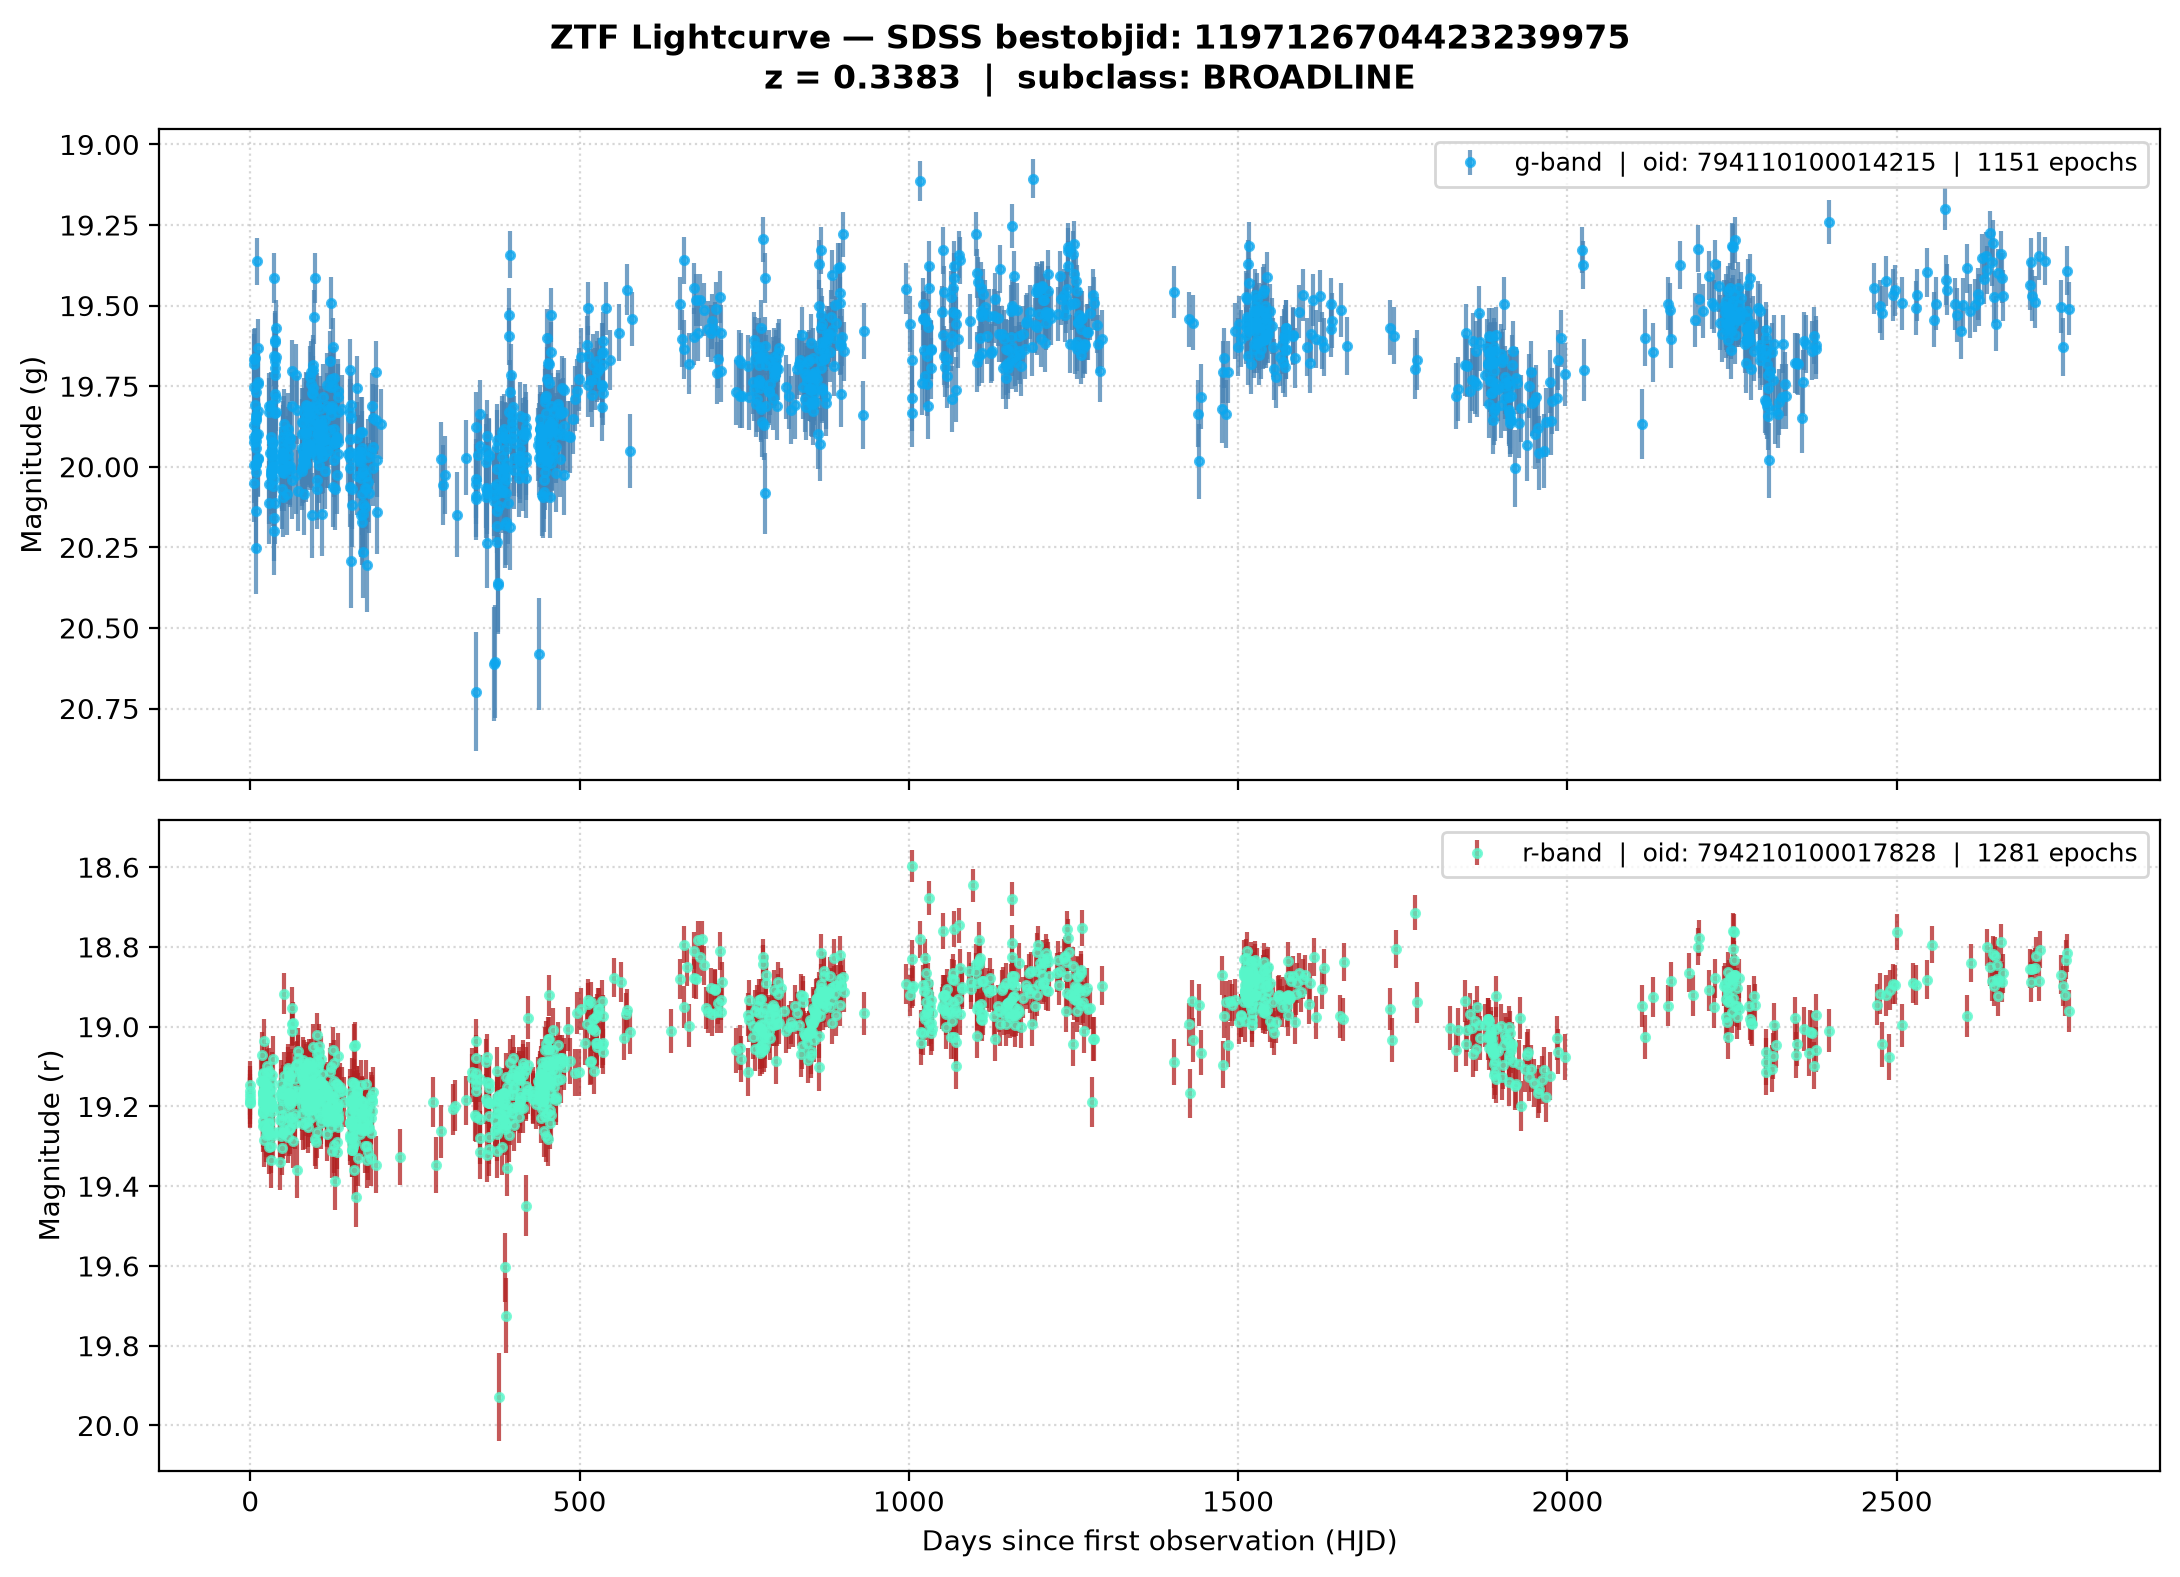

In [5]:
# ── Analysis ────────────────────────────────────────────────────────────
# Load metadata from HDF5 (re-run this cell after a fresh pipeline run)

_ac = cfg["analysis"]


def load_metadata(file_path: str | Path = OUTPUT_HDF5) -> pd.DataFrame:
    """Read the metadata table from HDF5."""
    return pd.read_hdf(file_path, key=f"/{HDF5_META_KEY}")


def filter_catalog(
    meta_df:      pd.DataFrame,
    min_g:        int   = _ac["min_g_epochs"],
    max_g:        int   = _ac["max_g_epochs"],
    min_r:        int   = _ac["min_r_epochs"],
    max_r:        int   = _ac["max_r_epochs"],
    min_redshift: float = _ac["min_redshift"],
    max_redshift: float = _ac["max_redshift"],
    sdss_class:   str   = _ac["sdss_class"],
    sdss_subclass: str  = _ac["sdss_subclass"],
) -> pd.DataFrame:
    """
    Filter the metadata catalog by epoch counts, redshift, and
    SDSS classification. All bounds are inclusive.
    Empty string for sdss_class / sdss_subclass means no filter.
    Returns a reset-indexed sub-DataFrame.
    """
    mask = (
        (meta_df["g_epochs"] >= min_g) &
        (meta_df["g_epochs"] <= max_g) &
        (meta_df["r_epochs"] >= min_r) &
        (meta_df["r_epochs"] <= max_r) &
        (meta_df["redshift"] >= min_redshift) &
        (meta_df["redshift"] <= max_redshift)
    )
    if sdss_class:
        mask &= meta_df["sdss_class"].str.upper() == sdss_class.upper()
    if sdss_subclass:
        mask &= (meta_df["sdss_subclass"]
                 .str.upper()
                 .str.contains(sdss_subclass.upper(), na=False))
    return meta_df[mask].reset_index(drop=True)


def load_lightcurve(
    bestobjid: int,
    file_path: str | Path = OUTPUT_HDF5,
) -> pd.DataFrame:
    """Load a single object's time-series DataFrame from HDF5."""
    key = f"/{HDF5_LC_ROOT}/{bestobjid}"
    return pd.read_hdf(file_path, key=key)


def plot_lightcurve(
    filtered_df: pd.DataFrame,
    index:       int = 0,
    file_path:   str | Path = OUTPUT_HDF5,
) -> tuple[np.ndarray, ...]:
    """
    Plot g and r band lightcurves for the object at `index` in
    the filtered metadata DataFrame.  Time is zeroed to the
    earliest observation across both bands.

    Returns (t_g, m_g, e_g, t_r, m_r, e_r) as clean NumPy arrays
    (NaN rows dropped, so arrays are not co-indexed).
    """
    if index >= len(filtered_df):
        raise IndexError(
            f"index={index} out of range for filtered catalog "
            f"of {len(filtered_df)} objects."
        )

    row       = filtered_df.iloc[index]
    bid       = int(row["bestobjid"])
    oid_g     = row.get("oid_g", None)
    oid_r     = row.get("oid_r", None)
    redshift  = row.get("redshift", np.nan)
    subclass  = row.get("sdss_subclass", "")

    df = load_lightcurve(bid, file_path)

    # Extract clean per-band arrays
    def _extract(df, tcol, mcol, ecol):
        if tcol not in df.columns:
            return np.array([]), np.array([]), np.array([])
        sub = df[[tcol, mcol, ecol]].dropna()
        return sub[tcol].to_numpy(), sub[mcol].to_numpy(), sub[ecol].to_numpy()

    t_g, m_g, e_g = _extract(df, "time_g", "mag_g", "magerr_g")
    t_r, m_r, e_r = _extract(df, "time_r", "mag_r", "magerr_r")

    # Zero time to the global first observation
    all_times = np.concatenate([
        t_g if len(t_g) else [],
        t_r if len(t_r) else [],
    ])
    t0 = float(np.min(all_times)) if len(all_times) > 0 else 0.0
    t_g_z = t_g - t0
    t_r_z = t_r - t0

    # ── Plot ──
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

    subtitle = (
        f"z = {redshift:.4f}" if not np.isnan(float(redshift)) else "z = N/A"
    )
    if subclass:
        subtitle += f"  |  subclass: {subclass}"

    fig.suptitle(
        f"ZTF Lightcurve — SDSS bestobjid: {bid}\n{subtitle}",
        fontsize=12, fontweight="bold",
    )

    # g band
    if len(t_g_z) > 0:
        ax1.errorbar(
            t_g_z, m_g, yerr=e_g, fmt="o",
            color=wl_to_color(4814), ecolor="steelblue",
            markersize=3, alpha=0.75,
            label=f"g-band  |  oid: {oid_g}  |  {len(t_g_z)} epochs",
        )
        ax1.invert_yaxis()
        ax1.set_ylabel("Magnitude (g)")
        ax1.legend(loc="upper right", fontsize=9)
        ax1.grid(True, linestyle=":", alpha=0.5)
    else:
        ax1.text(0.5, 0.5, "No valid g-band observations",
                 transform=ax1.transAxes, ha="center", color="grey")

    # r band
    if len(t_r_z) > 0:
        ax2.errorbar(
            t_r_z, m_r, yerr=e_r, fmt="o",
            color=wl_to_color(6366), ecolor="firebrick",
            markersize=3, alpha=0.75,
            label=f"r-band  |  oid: {oid_r}  |  {len(t_r_z)} epochs",
        )
        ax2.invert_yaxis()
        ax2.set_ylabel("Magnitude (r)")
        ax2.set_xlabel("Days since first observation (HJD)")
        ax2.legend(loc="upper right", fontsize=9)
        ax2.grid(True, linestyle=":", alpha=0.5)
    else:
        ax2.text(0.5, 0.5, "No valid r-band observations",
                 transform=ax2.transAxes, ha="center", color="grey")
        ax2.set_xlabel("Days since first observation (HJD)")

    plt.tight_layout()
    plt.show()

    return t_g, m_g, e_g, t_r, m_r, e_r


# ── Example usage ───────────────────────────────────────────────────────
# Reload metadata from file (works even without re-running the pipeline)
metadata = load_metadata()
print(f"Total objects in store: {len(metadata)}")
print(metadata[["bestobjid","redshift","sdss_subclass",
                 "g_epochs","r_epochs"]].to_string())

# Apply filters from config (edit TOML cell to change thresholds)
filtered = filter_catalog(metadata)
print(f"\nObjects passing filters: {len(filtered)}")
print(filtered[["bestobjid","redshift","sdss_subclass",
                 "g_epochs","r_epochs"]].to_string())

# Plot object at index 0 of the filtered set and get clean arrays
if not filtered.empty:
    t_g, m_g, e_g, t_r, m_r, e_r = plot_lightcurve(filtered, index=0)
else:
    print("No objects pass current filter criteria.")
